# 01 — Synthetic Occlusion (bản M_gt, Kaggle)

Bản sao `01_synthetic_occlusion.ipynb` với các thay đổi:

- **Input xe:** `kaggle/input/synthetic_occ_new/stanford_clean/` → `x_gt_clean_512/`, `M_gt_512/`, `metadata_clean.csv` (cột `x_gt`, `m_gt`).
- **COCO occluder:** tải **val2017** + annotations giống notebook gốc (`COCO_ANN_URL`, `COCO_IMG_URL`), cache dưới `/kaggle/working/data_prep_outputs/coco_cache/`.
- **Không** chạy letterbox Stanford gốc (Task 1); ảnh 512 + mask SAM đã có sẵn.

Output giữ layout gốc: `synthetic_occ/x_gt`, `x_occ`, `masks`, `metadata_synthetic_occ.csv`, ZIP, QC, smoke-test SD (tùy chọn).

> **Cấu trúc Input Kaggle:** Dataset thường là `.../synthetic_occ_new/stanford_clean/` chứa 3 mục trên. Nếu không có lớp `stanford_clean`, đặt `STANFORD_BUNDLE = Path("/kaggle/input/synthetic_occ_new")` trong cell config.


In [ ]:
import sys

# Cài các gói cần thiết — bỏ qua nếu đã có
!{sys.executable} -m pip install -q \
    pycocotools \
    opencv-python \
    Pillow \
    numpy pandas tqdm matplotlib \
    diffusers transformers accelerate \
    xformers \
    huggingface_hub

print("OK — all packages ready")


In [ ]:
# ─────────────────────────────────────────────
# CELL 2 — Config (Kaggle + bundle M_gt)
# ─────────────────────────────────────────────
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset đã chuẩn bị (đặt cạnh notebook trên Kaggle Input)
STANFORD_BUNDLE = Path("/kaggle/input/synthetic_occ_new/stanford_clean")
XGT_CLEAN_DIR = STANFORD_BUNDLE / "x_gt_clean_512"
MGT_DIR = STANFORD_BUNDLE / "M_gt_512"
CLEAN_META_CSV = STANFORD_BUNDLE / "metadata_clean.csv"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images(dir_path: Path) -> int:
    if not dir_path.exists():
        return 0
    return sum(1 for p in dir_path.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


OUTPUT_BASE = Path("/kaggle/working/data_prep_outputs")

SYNTH_DIR = OUTPUT_BASE / "synthetic_occ"
GT_DIR = SYNTH_DIR / "x_gt"
OCC_DIR = SYNTH_DIR / "x_occ"
MASK_DIR = SYNTH_DIR / "masks"
SYNTH_META_CSV = OUTPUT_BASE / "metadata_synthetic_occ.csv"

COCO_CACHE_DIR = OUTPUT_BASE / "coco_cache"
COCO_IMG_DIR = COCO_CACHE_DIR / "coco_val2017"
COCO_ANN_FILE = COCO_CACHE_DIR / "annotations" / "instances_val2017.json"

for d in [GT_DIR, OCC_DIR, MASK_DIR, COCO_IMG_DIR, COCO_ANN_FILE.parent]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

TARGET_SIZE = 512
PAD_VALUE = 128

IOU_MIN = 0.20
IOU_MAX = 0.80
MAX_PASTE_TRIES = 50

BIN_EDGES = [(0.20, 0.40), (0.40, 0.60), (0.60, 0.80)]
TARGET_SAMPLES = 10000
SAMPLES_PER_BIN = TARGET_SAMPLES // len(BIN_EDGES)

assert STANFORD_BUNDLE.is_dir(), f"Thiếu bundle: {STANFORD_BUNDLE}"
assert CLEAN_META_CSV.is_file(), f"Thiếu {CLEAN_META_CSV}"

print(f"STANFORD_BUNDLE : {STANFORD_BUNDLE}")
print(f"  x_gt_clean_512: {XGT_CLEAN_DIR} ({count_images(XGT_CLEAN_DIR):,} images)")
print(f"  M_gt_512       : {MGT_DIR}")
print(f"  metadata_clean : {CLEAN_META_CSV}")
print(f"OUTPUT_BASE      : {OUTPUT_BASE}")
print(f"SYNTH_DIR        : {SYNTH_DIR}")
print(f"COCO_CACHE_DIR   : {COCO_CACHE_DIR}")
print(f"Device           : {DEVICE} | dtype={DTYPE}")
print(f"IOU range        : [{IOU_MIN}, {IOU_MAX}]  |  bins={BIN_EDGES}")
print(f"Target           : {TARGET_SAMPLES:,} ảnh  ({SAMPLES_PER_BIN:,}/bin × {len(BIN_EDGES)} bins)")


## Bước chuẩn bị — Kiểm tra bundle (thay Task 1 letterbox)

Ảnh 512×512 và `M_gt` đã có từ pipeline SAM; chỉ kiểm tra file và CSV.


In [ ]:
# ─────────────────────────────────────────────
# CELL 3b — Kiểm tra nhanh bundle
# ─────────────────────────────────────────────
import cv2

clean_df = pd.read_csv(CLEAN_META_CSV)
need = {"x_gt", "m_gt"}
assert need <= set(clean_df.columns), f"CSV thiếu cột {need - set(clean_df.columns)}"

n_ok = 0
for _, r in clean_df.iterrows():
    if (XGT_CLEAN_DIR / str(r["x_gt"])).is_file() and (MGT_DIR / str(r["m_gt"])).is_file():
        n_ok += 1

print(f"metadata_clean rows : {len(clean_df):,}")
print(f"Cặp file tồn tại    : {n_ok:,}")
assert n_ok > 0, "Không có dòng nào khớp file trên disk"
clean_df.head()


## Task 2 — Synthetic Occlusion Pipeline (COCO Occluder)

Giống `01_synthetic_occlusion.ipynb`: tải COCO val2017, build bank, dán occluder; **mask xe = M_gt** thay Otsu.


In [ ]:
# ─────────────────────────────────────────────
# CELL 6 — Tải COCO val2017 (nếu chưa có)
# ─────────────────────────────────────────────
import urllib.request
import zipfile
import shutil

COCO_ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
COCO_IMG_URL = "http://images.cocodataset.org/zips/val2017.zip"   # ~1 GB


def download_and_extract(url: str, dest_dir: Path, zip_name: str):
    zip_path = dest_dir / zip_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print(f"Đang tải {url} ...")
        urllib.request.urlretrieve(url, str(zip_path))
        print(f"Tải xong: {zip_path}")
    else:
        print(f"Zip đã tồn tại: {zip_path}")

    print(f"Giải nén vào {dest_dir} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(str(dest_dir))
    print("Xong!")


# 1) Annotations
if not COCO_ANN_FILE.exists():
    ann_root = COCO_CACHE_DIR / "annotations"
    download_and_extract(COCO_ANN_URL, ann_root, "annotations.zip")

    nested = ann_root / "annotations" / "instances_val2017.json"
    direct = ann_root / "instances_val2017.json"
    if nested.exists() and not direct.exists():
        shutil.move(str(nested), str(direct))
else:
    print(f"Annotation đã có: {COCO_ANN_FILE}")

# 2) Images
coco_imgs = list(COCO_IMG_DIR.glob("*.jpg"))
if len(coco_imgs) < 100:
    download_and_extract(COCO_IMG_URL, COCO_CACHE_DIR, "val2017.zip")
    extracted = COCO_CACHE_DIR / "val2017"
    if extracted.exists() and extracted != COCO_IMG_DIR:
        COCO_IMG_DIR.mkdir(parents=True, exist_ok=True)
        for p in extracted.glob("*.jpg"):
            dst = COCO_IMG_DIR / p.name
            if not dst.exists():
                shutil.move(str(p), str(dst))
else:
    print(f"COCO images đã có: {len(coco_imgs):,} files trong {COCO_IMG_DIR}")


In [ ]:
# ─────────────────────────────────────────────
# CELL 7 — Build COCO Occluder Bank
# ─────────────────────────────────────────────
import numpy as np
import cv2
from pycocotools.coco import COCO
import pycocotools.mask as coco_mask_util

OCCLUDER_CATS = {
    "person", "bus", "truck", "motorcycle",
    "bicycle", "traffic light", "stop sign",
}

print(f"Đang load COCO annotations từ: {COCO_ANN_FILE}")
coco_api = COCO(str(COCO_ANN_FILE))

cat_ids = coco_api.getCatIds(catNms=list(OCCLUDER_CATS))
print(f"Categories được dùng: {len(cat_ids)} — {OCCLUDER_CATS}")

ann_ids = coco_api.getAnnIds(catIds=cat_ids)
anns = coco_api.loadAnns(ann_ids)
print(f"Tổng annotations COCO làm occluder: {len(anns):,}")


def coco_ann_to_binary_mask(ann: dict, img_h: int, img_w: int) -> np.ndarray:
    seg = ann["segmentation"]

    if isinstance(seg, list):
        rle = coco_mask_util.frPyObjects(seg, img_h, img_w)
        rle = coco_mask_util.merge(rle)

    elif isinstance(seg, dict):
        counts = seg["counts"]

        if isinstance(counts, list):
            rle = coco_mask_util.frPyObjects(seg, img_h, img_w)

        else:
            if isinstance(counts, str):
                seg = {**seg, "counts": counts.encode("utf-8")}
            rle = seg

    else:
        raise ValueError(f"Segmentation format không hỗ trợ: {type(seg)}")

    return coco_mask_util.decode(rle).astype(np.uint8)


def build_occluder_bank(anns: list, coco_img_dir: Path, coco_api: COCO):
    bank = []
    for ann in anns:
        img_id = ann["image_id"]
        img_info = coco_api.imgs[img_id]
        img_path = coco_img_dir / img_info["file_name"]

        if not img_path.exists():
            continue

        img_h = img_info["height"]
        img_w = img_info["width"]

        mask = coco_ann_to_binary_mask(ann, img_h, img_w)

        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue
        bw = xs.max() - xs.min()
        bh = ys.max() - ys.min()
        if bw < 32 or bh < 32:
            continue

        bank.append({
            "mask": mask,
            "bbox": ann["bbox"],
            "img_path": img_path,
            "img_h": img_h,
            "img_w": img_w,
        })

    return bank


occluder_bank = build_occluder_bank(anns, COCO_IMG_DIR, coco_api)
print(f"Occluder bank size (after size filter): {len(occluder_bank):,}")


In [ ]:
# ─────────────────────────────────────────────
# CELL 8 — Paste Occluder & Sinh (x_gt, x_occ, M) — mask xe = M_gt
#   ► occlusion_ratio = giao(occ_mask, M_gt) / area(M_gt)
# ─────────────────────────────────────────────
from tqdm.auto import tqdm


def letterbox(img: np.ndarray, size: int = 512, pad: int = 128) -> np.ndarray:
    h, w = img.shape[:2]
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((size, size, 3), pad, dtype=np.uint8)
    x_off = (size - new_w) // 2
    y_off = (size - new_h) // 2
    canvas[y_off : y_off + new_h, x_off : x_off + new_w] = resized
    return canvas


def compute_occlusion_ratio(occ_mask_01: np.ndarray, car_mask_01: np.ndarray) -> float:
    car_area = float(car_mask_01.sum())
    if car_area == 0:
        return 0.0
    inter = float((occ_mask_01 & car_mask_01).sum())
    return inter / car_area


def paste_occluder_on_target(
    target_bgr: np.ndarray,
    occ_entry: dict,
    car_mask: np.ndarray,
    iou_min: float = IOU_MIN,
    iou_max: float = IOU_MAX,
    max_tries: int = MAX_PASTE_TRIES,
    scale_range: tuple = (0.25, 0.70),
):
    H, W = target_bgr.shape[:2]

    car_ys, car_xs = np.where(car_mask > 0)
    if len(car_xs) == 0:
        car_ys = np.arange(H)
        car_xs = np.arange(W)

    donor = cv2.imread(str(occ_entry["img_path"]), cv2.IMREAD_COLOR)
    if donor is None:
        return None, None, 0.0, False

    seg_mask = occ_entry["mask"]
    ys, xs = np.where(seg_mask)
    if len(xs) == 0:
        return None, None, 0.0, False

    y0c, y1c = ys.min(), ys.max() + 1
    x0c, x1c = xs.min(), xs.max() + 1
    crop_img = donor[y0c:y1c, x0c:x1c]
    crop_mask = seg_mask[y0c:y1c, x0c:x1c]

    for _ in range(max_tries):
        scale_factor = random.uniform(*scale_range)
        new_w = max(16, int(W * scale_factor))
        scale = new_w / max(1, crop_img.shape[1])
        new_h = max(16, int(crop_img.shape[0] * scale))

        r_img = cv2.resize(crop_img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        r_mask = cv2.resize(crop_mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

        angle = random.uniform(-20, 20)
        cx, cy = new_w / 2, new_h / 2
        M_rot = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        r_img = cv2.warpAffine(
            r_img, M_rot, (new_w, new_h),
            borderMode=cv2.BORDER_CONSTANT, borderValue=0,
        )
        r_mask = cv2.warpAffine(
            r_mask, M_rot, (new_w, new_h),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0,
        )

        idx = random.randint(0, len(car_xs) - 1)
        cx_car = int(car_xs[idx])
        cy_car = int(car_ys[idx])

        px = cx_car - new_w // 2
        py = cy_car - new_h // 2

        src_x0 = max(0, -px)
        dst_x0 = max(0, px)
        src_y0 = max(0, -py)
        dst_y0 = max(0, py)
        src_x1 = min(new_w, W - px) if px >= 0 else min(new_w, W)
        src_y1 = min(new_h, H - py) if py >= 0 else min(new_h, H)
        dst_x1 = dst_x0 + (src_x1 - src_x0)
        dst_y1 = dst_y0 + (src_y1 - src_y0)

        if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
            continue

        patch_img = r_img[src_y0:src_y1, src_x0:src_x1]
        patch_mask = r_mask[src_y0:src_y1, src_x0:src_x1]

        canvas_mask = np.zeros((H, W), dtype=np.uint8)
        canvas_mask[dst_y0:dst_y1, dst_x0:dst_x1] = patch_mask

        ratio = compute_occlusion_ratio(canvas_mask, car_mask)

        if iou_min <= ratio <= iou_max:
            x_occ = target_bgr.copy()
            alpha = patch_mask[:, :, None].astype(np.float32)
            fg = patch_img.astype(np.float32)
            bg = x_occ[dst_y0:dst_y1, dst_x0:dst_x1].astype(np.float32)
            blended = alpha * fg + (1 - alpha) * bg
            x_occ[dst_y0:dst_y1, dst_x0:dst_x1] = blended.astype(np.uint8)

            return x_occ, (canvas_mask * 255).astype(np.uint8), ratio, True

    return None, None, 0.0, False


def run_synthetic_occlusion(
    clean_meta: pd.DataFrame,
    xgt_dir: Path,
    mgt_dir: Path,
    gt_dir: Path,
    occ_dir: Path,
    mask_dir: Path,
    occluder_bank: list,
    target_total: int = TARGET_SAMPLES,
    bin_edges: list = None,
    max_tries: int = MAX_PASTE_TRIES,
):
    if bin_edges is None:
        bin_edges = BIN_EDGES
    if not occluder_bank:
        raise RuntimeError("occluder_bank rỗng — hãy chạy cell build occluder bank trước.")

    work_rows = []
    for _, row in clean_meta.iterrows():
        xp = xgt_dir / str(row["x_gt"])
        mp = mgt_dir / str(row["m_gt"])
        if xp.is_file() and mp.is_file():
            work_rows.append(row.to_dict())

    if not work_rows:
        raise RuntimeError("Không có dòng metadata nào khớp file trên disk")

    random.shuffle(work_rows)

    n_bins = len(bin_edges)
    target_per_bin = target_total // n_bins
    bin_counts = [0] * n_bins
    rows = []
    n_fail = 0
    img_idx = 0
    suffix_counters = [0] * n_bins

    pbar = tqdm(total=target_total, desc="Bin-balanced occlusion")

    while sum(bin_counts) < target_total:
        if img_idx >= len(work_rows):
            random.shuffle(work_rows)
            img_idx = 0

        rec = work_rows[img_idx]
        img_idx += 1

        target = cv2.imread(str(xgt_dir / rec["x_gt"]), cv2.IMREAD_COLOR)
        mgt = cv2.imread(str(mgt_dir / rec["m_gt"]), cv2.IMREAD_GRAYSCALE)
        if target is None or mgt is None:
            n_fail += 1
            continue
        if target.shape[:2] != (TARGET_SIZE, TARGET_SIZE):
            target = letterbox(target, TARGET_SIZE, PAD_VALUE)
        if mgt.shape[:2] != (TARGET_SIZE, TARGET_SIZE):
            mgt = cv2.resize(mgt, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)
        car_mask = (mgt > 127).astype(np.uint8)

        needed_bins = [i for i, cnt in enumerate(bin_counts) if cnt < target_per_bin]
        if not needed_bins:
            break

        target_bin = min(needed_bins, key=lambda i: bin_counts[i])
        bin_lo, bin_hi = bin_edges[target_bin]

        occ_entry = random.choice(occluder_bank)
        x_occ, occ_mask, ratio, ok = paste_occluder_on_target(
            target, occ_entry, car_mask,
            iou_min=bin_lo, iou_max=bin_hi,
            max_tries=max_tries,
        )

        if not ok:
            n_fail += 1
            continue

        base_stem = Path(str(rec["x_gt"])).stem
        suffix_counters[target_bin] += 1
        stem = f"{base_stem}_b{target_bin}_{suffix_counters[target_bin]:04d}"

        gt_save = gt_dir / f"{stem}.jpg"
        occ_save = occ_dir / f"{stem}.jpg"
        mask_save = mask_dir / f"{stem}.png"

        cv2.imwrite(str(gt_save), target, [cv2.IMWRITE_JPEG_QUALITY, 95])
        cv2.imwrite(str(occ_save), x_occ, [cv2.IMWRITE_JPEG_QUALITY, 95])
        cv2.imwrite(str(mask_save), occ_mask)

        row_out = {
            "stem": stem,
            "x_gt": gt_save.name,
            "x_occ": occ_save.name,
            "mask": mask_save.name,
            "occlusion_ratio": round(ratio, 4),
            "bin_idx": target_bin,
            "bin_label": f"{int(bin_lo * 100)}-{int(bin_hi * 100)}%",
            "occluder_img": occ_entry["img_path"].name,
            "clean_x_gt": rec["x_gt"],
            "clean_m_gt": rec["m_gt"],
        }
        for k, v in rec.items():
            if k in ("x_gt", "m_gt"):
                continue
            row_out[f"clean_{k}"] = v
        rows.append(row_out)

        bin_counts[target_bin] += 1
        pbar.update(1)

    pbar.close()

    meta = pd.DataFrame(rows)
    return meta, sum(bin_counts), n_fail, bin_counts


clean_meta_df = pd.read_csv(CLEAN_META_CSV)
meta_df, n_ok, n_fail, bin_counts = run_synthetic_occlusion(
    clean_meta_df,
    XGT_CLEAN_DIR,
    MGT_DIR,
    GT_DIR,
    OCC_DIR,
    MASK_DIR,
    occluder_bank,
    target_total=TARGET_SAMPLES,
    bin_edges=BIN_EDGES,
    max_tries=MAX_PASTE_TRIES,
)

meta_df.to_csv(SYNTH_META_CSV, index=False)

print(f"\nSynthetic occlusion done")
print(f"  Success   : {n_ok:,}")
print(f"  Failed    : {n_fail:,}  (ratio ngoài range sau {MAX_PASTE_TRIES} lần thử)")
print(f"  IOU range : [{IOU_MIN}, {IOU_MAX}]")
for i, (lo, hi) in enumerate(BIN_EDGES):
    print(f"  Bin {i} ({int(lo * 100)}-{int(hi * 100)}%): {bin_counts[i]:,} ảnh")
print(f"  Metadata  : {SYNTH_META_CSV}")
meta_df.describe()


In [ ]:
# ─────────────────────────────────────────────
# CELL 8b — Đóng gói toàn bộ output thành 1 ZIP duy nhất
# ─────────────────────────────────────────────
import zipfile
from tqdm.auto import tqdm

ZIP_OUTPUT = Path("/kaggle/working/synthetic_occ_full.zip")

all_files = []
for src_dir, arc_prefix in [
    (GT_DIR, "synthetic_occ/x_gt"),
    (OCC_DIR, "synthetic_occ/x_occ"),
    (MASK_DIR, "synthetic_occ/masks"),
]:
    for f in sorted(src_dir.iterdir()):
        all_files.append((f, f"{arc_prefix}/{f.name}"))

all_files.append((SYNTH_META_CSV, "synthetic_occ/metadata_synthetic_occ.csv"))

print(f"Tổng file cần zip: {len(all_files):,}")

with zipfile.ZipFile(ZIP_OUTPUT, "w", zipfile.ZIP_DEFLATED, compresslevel=1) as zf:
    for fpath, arcname in tqdm(all_files, desc="Zipping"):
        zf.write(fpath, arcname)

size_mb = ZIP_OUTPUT.stat().st_size / 1e6
print(f"
Đã tạo: {ZIP_OUTPUT.name}")
print(f"Kích thước: {size_mb:.1f} MB")
print(f"Đường dẫn: {ZIP_OUTPUT}")


In [ ]:
# ─────────────────────────────────────────────
# CELL 9 — QC & Visualization (cột 5 = M_gt)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

meta_vis = pd.read_csv(SYNTH_META_CSV)

n_gt = len(list(GT_DIR.glob("*.jpg")))
n_occ = len(list(OCC_DIR.glob("*.jpg")))
n_mask = len(list(MASK_DIR.glob("*.png")))
n_csv = len(meta_vis)

print("=" * 60)
print("FILE COUNT VERIFICATION")
print(f"  x_gt/  : {n_gt:,}  jpg files")
print(f"  x_occ/ : {n_occ:,}  jpg files")
print(f"  masks/ : {n_mask:,}  png files")
print(f"  CSV    : {n_csv:,}  rows")

if n_gt == n_occ == n_mask == n_csv:
    print("  ✓  Tất cả 4 số đều khớp nhau")
else:
    print("  ✗  MISMATCH — kiểm tra lại!")

out_of_range = meta_vis[
    (meta_vis["occlusion_ratio"] < IOU_MIN) |
    (meta_vis["occlusion_ratio"] > IOU_MAX)
]
print(f"
OCCLUSION RATIO RANGE CHECK  [{IOU_MIN}, {IOU_MAX}]")
print(f"  Min   : {meta_vis['occlusion_ratio'].min():.4f}")
print(f"  Max   : {meta_vis['occlusion_ratio'].max():.4f}")
print(f"  Out-of-range rows: {len(out_of_range)}")

if len(meta_vis) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    meta_vis["occlusion_ratio"].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    bin_colors = ["#e74c3c", "#2ecc71", "#9b59b6"]
    for (lo, hi), color in zip(BIN_EDGES, bin_colors):
        ax.axvspan(lo, hi, alpha=0.12, color=color)
        ax.axvline(lo, color=color, linestyle="--", linewidth=1.2)
    ax.axvline(IOU_MAX, color=bin_colors[-1], linestyle="--", linewidth=1.2)
    patches = [mpatches.Patch(color=c, alpha=0.4, label=f"Bin {i} {int(lo*100)}-{int(hi*100)}%")
               for i, ((lo, hi), c) in enumerate(zip(BIN_EDGES, bin_colors))]
    ax.legend(handles=patches, fontsize=8)
    ax.set_xlabel("Occlusion Ratio")
    ax.set_ylabel("Số ảnh")
    ax.set_title(f"Phân phối occlusion_ratio  (n={n_csv:,})")
    ax.set_xlim(0, 1)

    ax2 = axes[1]
    bin_labels = [f"{int(lo*100)}-{int(hi*100)}%" for lo, hi in BIN_EDGES]
    bin_cnts = [
        ((meta_vis["occlusion_ratio"] >= lo) & (meta_vis["occlusion_ratio"] < hi)).sum()
        for lo, hi in BIN_EDGES
    ]
    bars = ax2.bar(bin_labels, bin_cnts, color=bin_colors, edgecolor="white")
    ax2.axhline(TARGET_SAMPLES // len(BIN_EDGES), color="gray", linestyle="--",
                linewidth=1, label=f"Target/bin = {TARGET_SAMPLES // len(BIN_EDGES):,}")
    for bar, cnt in zip(bars, bin_cnts):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=9)
    ax2.set_xlabel("Occlusion Bin")
    ax2.set_ylabel("Số mẫu")
    ax2.set_title("Số mẫu theo bin (cân bằng kiểm tra)")
    ax2.legend()
    plt.tight_layout()
    plt.show()

show_per_bin = 2
sample_rows = []
for lo, hi in BIN_EDGES:
    subset = meta_vis[(meta_vis["occlusion_ratio"] >= lo) &
                      (meta_vis["occlusion_ratio"] < hi)]
    if len(subset) >= show_per_bin:
        sample_rows.append(subset.sample(show_per_bin, random_state=SEED))
    elif len(subset) > 0:
        sample_rows.append(subset)

if sample_rows:
    samples = pd.concat(sample_rows).reset_index(drop=True)
    show_n = len(samples)

    fig, axes = plt.subplots(show_n, 5, figsize=(17, 3.0 * show_n))
    if show_n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["x_gt", "x_occ", "Mask (M)", "Overlay", "Car Mask (M_gt)"]

    for i, row in samples.iterrows():
        gt = cv2.cvtColor(cv2.imread(str(GT_DIR / row["x_gt"])), cv2.COLOR_BGR2RGB)
        occ = cv2.cvtColor(cv2.imread(str(OCC_DIR / row["x_occ"])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(MASK_DIR / row["mask"]), cv2.IMREAD_GRAYSCALE)

        overlay = gt.copy()
        overlay[mask > 127, 0] = np.clip(overlay[mask > 127, 0] * 0.4 + 200, 0, 255)

        mgt_vis = cv2.imread(str(MGT_DIR / row["clean_m_gt"]), cv2.IMREAD_GRAYSCALE)
        if mgt_vis is None:
            mgt_vis = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=np.uint8)
        if mgt_vis.shape[:2] != (TARGET_SIZE, TARGET_SIZE):
            mgt_vis = cv2.resize(mgt_vis, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)
        car_mask_vis = (mgt_vis > 127).astype(np.uint8) * 255

        for j, (img_data, cmap) in enumerate([
            (gt, None), (occ, None), (mask, "gray"), (overlay, None), (car_mask_vis, "gray")
        ]):
            axes[i, j].imshow(img_data, cmap=cmap)
            if i == 0:
                axes[i, j].set_title(col_titles[j], fontsize=9, fontweight="bold")
            axes[i, j].set_ylabel(
                f"bin={row.get('bin_label','?')}  occ={row.occlusion_ratio:.2f}",
                fontsize=7
            )
            axes[i, j].axis("off")

    plt.suptitle("QC Visual — GT / Occ / Mask / Overlay / M_gt", y=1.01)
    plt.tight_layout()
    plt.show()


## Task 3 — VRAM Check + SD Inpainting Smoke-test

**Mục tiêu:**
- Đo peak VRAM trước/sau khi load model
- Xác nhận `xformers` memory-efficient attention hoạt động
- Chạy 1 pass inpainting thực tế, in kết quả + thời gian inference
- Nếu VRAM không đủ: hướng dẫn fallback (CPU offload / attention slicing)

In [9]:
# ─────────────────────────────────────────────
# CELL 11 — VRAM Baseline (trước khi load model)
# ─────────────────────────────────────────────
import subprocess, time
import torch

def vram_info() -> dict:
    """Trả về dict VRAM info (GB). Chạy được cả khi không có GPU."""
    if not torch.cuda.is_available():
        return {"available": False}
    props   = torch.cuda.get_device_properties(0)
    total   = props.total_memory / 1024**3
    reserved= torch.cuda.memory_reserved(0)  / 1024**3
    alloc   = torch.cuda.memory_allocated(0) / 1024**3
    free    = total - reserved
    return {
        "available"   : True,
        "gpu_name"    : props.name,
        "total_gb"    : round(total,    2),
        "reserved_gb" : round(reserved, 2),
        "allocated_gb": round(alloc,    2),
        "free_gb"     : round(free,     2),
    }


def print_vram(label: str):
    info = vram_info()
    if not info["available"]:
        print(f"[{label}] No CUDA GPU found — running on CPU")
        return
    print(
        f"[{label}] GPU: {info['gpu_name']} | "
        f"Total: {info['total_gb']} GB | "
        f"Alloc: {info['allocated_gb']} GB | "
        f"Free: {info['free_gb']} GB"
    )


print_vram("Baseline (trước load model)")

# nvidia-smi snapshot
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
         "--format=csv,noheader,nounits"],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    print(f"\nnvidia-smi:\n  name | total(MiB) | used(MiB) | free(MiB)")
    for line in smi.splitlines():
        print(f"  {line}")
except FileNotFoundError:
    print("nvidia-smi không có — bỏ qua")

[Baseline (trước load model)] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 0.0 GB | Free: 14.56 GB

nvidia-smi:
  name | total(MiB) | used(MiB) | free(MiB)
  Tesla T4, 15360, 3, 14910
  Tesla T4, 15360, 3, 14910


In [10]:
# ─────────────────────────────────────────────
# CELL 12 — Load SD Inpainting + xFormers check
# ─────────────────────────────────────────────
from diffusers import StableDiffusionInpaintPipeline
import torch

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"

print(f"Đang load pipeline: {SD_MODEL_ID}")
print(f"Device: {DEVICE}  |  dtype: {DTYPE}")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    SD_MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,     # tắt để giảm VRAM
    requires_safety_checker=False,
)
pipe = pipe.to(DEVICE)

# ── xFormers check ───────────────────────────
xformers_ok = False
try:
    pipe.enable_xformers_memory_efficient_attention()
    xformers_ok = True
    print("xFormers: OK — memory efficient attention enabled")
except Exception as e:
    print(f"xFormers: NOT available ({e})")
    # Fallback: attention slicing — giảm VRAM ~20% nhưng chậm hơn
    pipe.enable_attention_slicing(slice_size="auto")
    print("Fallback: attention slicing enabled")

# VRAM sau khi load model
print_vram("Sau load model")

# Optional: CPU offload nếu VRAM < 8 GB
info = vram_info()
if info.get("available") and info["total_gb"] < 8:
    print("\nVRAM < 8 GB — enable sequential CPU offload để an toàn")
    pipe.enable_sequential_cpu_offload()
    print("CPU offload: enabled")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Đang load pipeline: runwayml/stable-diffusion-inpainting
Device: cuda  |  dtype: torch.float16


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


xFormers: OK — memory efficient attention enabled
[Sau load model] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 2.01 GB | Free: 12.5 GB


Input image : (512, 512)  |  occlusion ratio: 0.568
Mask pixels : 114,455 / 262,144 = 43.7%

Đang chạy SD inpainting (20 steps) ...


  0%|          | 0/20 [00:00<?, ?it/s]


Peak VRAM  : 2677 MiB  (2.61 GiB)
Inference  : 4.13s  |  xFormers: True
[Sau inference] GPU: Tesla T4 | Total: 14.56 GB | Alloc: 2.02 GB | Free: 11.67 GB


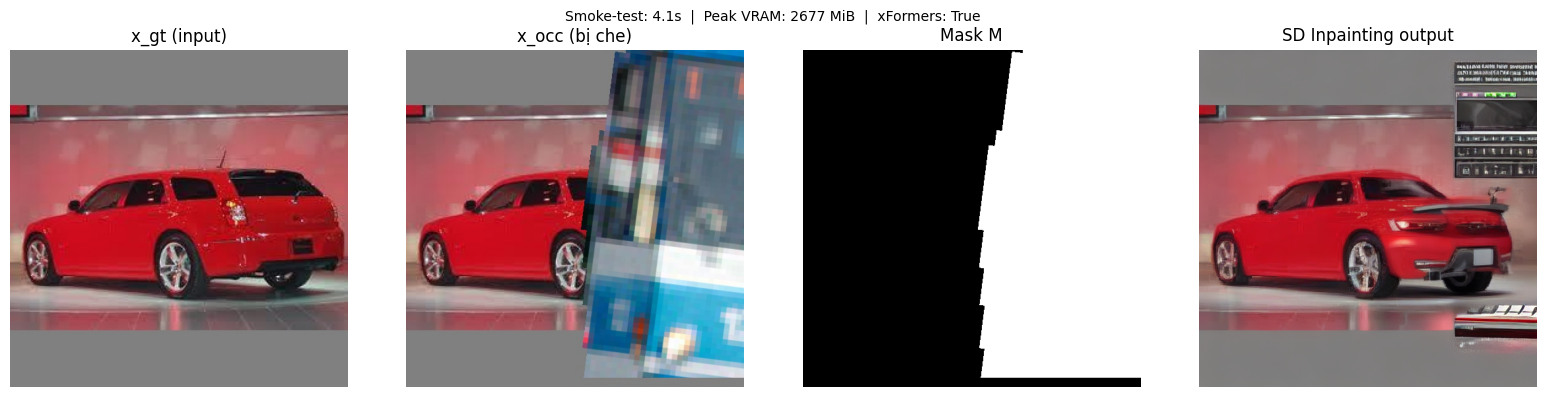


SMOKE-TEST REPORT
  GPU           : Tesla T4
  VRAM total    : 14.56 GiB
  Peak VRAM used: 2.61 GiB
  Headroom      : 11.95 GiB
  ✓  Headroom đủ cho training batch nhỏ
  xFormers      : ✓ enabled
  Inference time: 4.13s / image  (20 steps)


In [11]:
# ─────────────────────────────────────────────
# CELL 13 — SD Inpainting Smoke-test (1 ảnh)
# ─────────────────────────────────────────────
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time

# Lấy 1 sample từ synthetic dataset vừa tạo
meta_vis = pd.read_csv(SYNTH_META_CSV)
sample   = meta_vis.sample(1, random_state=SEED).iloc[0]

s_gt   = sample["x_gt"]
s_occ  = sample["x_occ"]
s_mask = sample["mask"]
s_ratio = sample["occlusion_ratio"]

img_pil  = Image.open(GT_DIR   / s_gt  ).convert("RGB").resize((512, 512))
mask_pil = Image.open(MASK_DIR / s_mask).convert("L").resize((512, 512))

# Đảm bảo mask binary: 255 = vùng inpaint (che khuất)
mask_arr = np.array(mask_pil)
mask_arr = (mask_arr > 127).astype(np.uint8) * 255
mask_pil = Image.fromarray(mask_arr)


print(f"Input image : {img_pil.size}  |  occlusion ratio: {sample.occlusion_ratio:.3f}")
print(f"Mask pixels : {(mask_arr > 0).sum():,} / {512*512:,} = {(mask_arr > 0).mean()*100:.1f}%")

# Reset peak VRAM counter
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

PROMPT = (
    "a car, clean and complete, photorealistic, "
    "no occlusion, same color and texture as surrounding"
)
NEG_PROMPT = "blurry, distorted, extra wheels, extra cars, artifacts"

print("\nĐang chạy SD inpainting (20 steps) ...")
t0 = time.perf_counter()

with torch.inference_mode():
    result = pipe(
        prompt            = PROMPT,
        negative_prompt   = NEG_PROMPT,
        image             = img_pil,
        mask_image        = mask_pil,
        num_inference_steps = 20,
        guidance_scale    = 7.5,
        generator         = torch.Generator(device=DEVICE).manual_seed(SEED),
    ).images[0]

elapsed = time.perf_counter() - t0

# Peak VRAM
if torch.cuda.is_available():
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    print(f"\nPeak VRAM  : {peak_mb:.0f} MiB  ({peak_mb/1024:.2f} GiB)")
else:
    peak_mb = 0
    print("\nPeak VRAM  : N/A (CPU mode)")

print(f"Inference  : {elapsed:.2f}s  |  xFormers: {xformers_ok}")
print_vram("Sau inference")

# ── Visualize ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_pil);                        axes[0].set_title("x_gt (input)")
axes[1].imshow(Image.open(OCC_DIR / sample.x_occ)); axes[1].set_title("x_occ (bị che)")
axes[2].imshow(mask_pil, cmap="gray");          axes[2].set_title("Mask M")
axes[3].imshow(result);                         axes[3].set_title("SD Inpainting output")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Smoke-test: {elapsed:.1f}s  |  Peak VRAM: {peak_mb:.0f} MiB  |  xFormers: {xformers_ok}",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Summary report ───────────────────────────
print("\n" + "="*55)
print("SMOKE-TEST REPORT")
print("="*55)
info = vram_info()
if info.get("available"):
    print(f"  GPU           : {info['gpu_name']}")
    print(f"  VRAM total    : {info['total_gb']} GiB")
    print(f"  Peak VRAM used: {peak_mb/1024:.2f} GiB")
    headroom = info['total_gb'] - peak_mb/1024
    print(f"  Headroom      : {headroom:.2f} GiB")
    if headroom < 1.5:
        print("  ⚠️  Headroom thấp — tăng offload hoặc giảm batch size khi train")
    else:
        print("  ✓  Headroom đủ cho training batch nhỏ")
else:
    print("  Running on CPU — inference rất chậm, dùng Kaggle GPU để train")
print(f"  xFormers      : {'✓ enabled' if xformers_ok else '✗ fallback attention slicing'}")
print(f"  Inference time: {elapsed:.2f}s / image  (20 steps)")
print("="*55)